In [2]:
import sys
!{sys.executable} -m pip install -qq langchain

In [7]:
import pandas as pd
import pandasql as psql
import re
import matplotlib.pyplot as plt

In [17]:
def load_data():
    sales = pd.read_csv("C:\myCODE\AgenticAIReporting\data\sales.csv")
    products = pd.read_csv("C:\myCODE\AgenticAIReporting\data\products.csv")
    stores = pd.read_csv("C:\myCODE\AgenticAIReporting\data\stores.csv")

    table_metadata = """Table: products; Columns: product_id	,product_name ,category	,brand	,price;
                        Table: sales; Columns: sale_id	,product_id	,store_id	,quantity	,sale_date;
                        Table: stores; Columns:store_id	,store_name	,city	,state	,region; """
    
    return sales, products, stores, table_metadata

sales, products, stores, table_metadata = load_data()

In [19]:
products.sample(3)

,product_id,product_name,category,brand,price
9,10,Product_10,Accessories,Samsung,325.72
366,367,Product_367,Clothing,Apple,1869.20
593,594,Product_594,Home,Dyson,1521.78


In [115]:
sales.sample(3)

,sale_id,product_id,store_id,quantity,sale_date
35478,35479,835,197,14,2024-10-26
8106,8107,942,159,10,2024-07-27
71785,71786,87,156,12,2024-12-09


In [20]:
stores.sample(3)

,store_id,store_name,city,state,region
124,125,Store_125,Los Angeles,CA,West
187,188,Store_188,San Francisco,NY,East
15,16,Store_16,Chicago,WA,East


In [47]:
def load_prompt(Question:str):
        table_metadata = """Table: products; Columns: product_id	,product_name ,category	,brand	,price;
                    Table: sales; Columns: sale_id	,product_id	,store_id	,quantity	,sale_date;
                    Table: stores; Columns:store_id	,store_name	,city	,state	,region; """

        prompt = f"""You are a SQL data analyst. You help write sql code and visualize the results in charts.

        Write a SQL query to answer the following question with only the tables/columns provided in metadata: 
        Only return the SQL query starting with the Keyword "SQLQuery": Do not explain.
        Suggest a visualization to display above Result, starting with the Keyword "Chart:".Do not explain. choose one of (bar, pie, line, table)
        Add comment in query field selection to indicate 2 coordinates for the chart. use ("-- x coordinate", "-- y coordinate") Do not rename the query result field names.
        Sample:
        SQLQuery:
        SELECT d.department_name as Department             -- x coordinate (Department)
                , count(e.employee_id) as Employees        -- y coordinate (Employee Count)
        FROM employee e
        JOIN department d on e.department_id=d.department_id

        Chart: bar chart


        Metadata = {table_metadata} 
        Question: {Question} """

        return (prompt)
Question = "show volume of sales, revenue by product category"
p =load_prompt(Question)   
print(p)     

You are a SQL data analyst. You help write sql code and visualize the results in charts.

        Write a SQL query to answer the following question with only the tables/columns provided in metadata: 
        Only return the SQL query starting with the Keyword "SQLQuery": Do not explain.
        Suggest a visualization to display above Result, starting with the Keyword "Chart:".Do not explain. choose one of (bar, pie, line, table)
        Add comment in query field selection to indicate 2 coordinates for the chart. use ("-- x coordinate", "-- y coordinate") Do not rename the query result field names.
        Sample:
        SQLQuery:
        SELECT d.department_name as Department             -- x coordinate (Department)
                , count(e.employee_id) as Employees        -- y coordinate (Employee Count)
        FROM employee e
        JOIN department d on e.department_id=d.department_id

        Chart: bar chart


        Metadata = Table: products; Columns: product_id	,product_

In [30]:
import os
import langchain
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-5-nano",api_key=os.getenv("OPENAI_API_KEY"))

#prompt template
from langchain.prompts import PromptTemplate
template = """You are a SQL data analyst. You help write sql code and visualize the results in charts.

Write a SQL query to answer the following question with only the tables/columns provided in metadata: 
Only return the SQL query starting with the Keyword "SQLQuery": Do not explain.
Suggest a visualization to display above Result, starting with the Keyword "Chart:".Do not explain. choose one of (bar, pie, line, table)
Add comment in query field selection to indicate 2 coordinates for the chart. use ("-- x coordinate", "-- y coordinate") Do not rename the query result field names.
Sample:
SQLQuery:
SELECT d.department_name as Department             -- x coordinate (Department)
        , count(e.employee_id) as Employees        -- y coordinate (Employee Count)
FROM employee e
JOIN department d on e.department_id=d.department_id

Chart: bar chart


Metadata = {metadata} 
Question: {question}"""
prompt = PromptTemplate(template=template, input_variables=["metadata","question"])

# Run
table_metadata = """Table: Products; Columns: product_id	,product_name ,category	,brand	,price;
                    Table: Sales; Columns: sale_id	,product_id	,store_id	,quantity	,sale_date;
                    Table: Stores; Columns:store_id	,store_name	,city	,state	,region; """

from langchain.schema import StrOutputParser
chain = prompt | llm | StrOutputParser()

def invoke_llm_openai(question:str):
    response = chain.invoke({"question": question,"metadata":table_metadata})
    return response

In [60]:
def parse_sql_and_chart(parse_text):
    # Extract SQL query
    sql_query_match = re.search(r"sqlquery:\s*(select[\s\S]+?)\s*chart:", parse_text, re.IGNORECASE)
    sql_query = sql_query_match.group(1).strip() if sql_query_match else None

    # Extract chart suggestion
    chart_match = re.search(r"Chart:\s*(.*)", parse_text, re.IGNORECASE)
    chart_text = chart_match.group(1).strip() 

    # Map common chart types
    if "line" in chart_text:
        chart_type = "line"
    elif "pie" in chart_text:
        chart_type = "pie"
    elif "bar" in chart_text:
        chart_type = "bar"
    else:
        chart_type = "table"

    # Extract x and y coordinates from SQL comments
    # Look for "-- X coordinate (...)" or "-- Y coordinate (...)" in SELECT lines
    x_coord, y_coord = None, None
    select_lines = parse_text.splitlines()
    for line in select_lines:
        if "-- x coordinate" in line:
            if " as " in line:
                x_coord = line.split("as")[1].split()[0].strip().strip(',')
            elif " AS " in line:
                x_coord = line.split("AS")[1].split()[0].strip().strip(',')    
            else:
                x_coord = line.split(".")[1].split()[0].strip().strip(',')  
        if "-- y coordinate" in line:
            if " as " in line:
                y_coord = line.split("as")[1].split()[0].strip().strip(',') 
            elif " AS " in line:
                y_coord = line.split("AS")[1].split()[0].strip().strip(',')     
            else:
                y_coord = line.split(".")[1].split()[0].strip().strip(',')  

    return {
        "sql_query": sql_query,
        "chart": chart_type,
        "x_coordinate": x_coord,
        "y_coordinate": y_coord
    }

st = """SQLQuery:

SELECT s.sale_date                       -- x coordinate (Sale Date)
       , SUM(s.quantity) AS SalesVolume  -- y coordinate (Sales Volume)
FROM sales s
JOIN products p ON s.product_id = p.product_id
WHERE p.category = 'Books'
GROUP BY s.sale_date
ORDER BY s.sale_date;


Chart: line chart"""
parsed = parse_sql_and_chart(st)
print("SQLQuery:\n", parsed['sql_query'])
print("Chart:\n", parsed)

SQLQuery:
 SELECT s.sale_date                       -- x coordinate (Sale Date)
       , SUM(s.quantity) AS SalesVolume  -- y coordinate (Sales Volume)
FROM sales s
JOIN products p ON s.product_id = p.product_id
WHERE p.category = 'Books'
GROUP BY s.sale_date
ORDER BY s.sale_date;
Chart:
 {'sql_query': "SELECT s.sale_date                       -- x coordinate (Sale Date)\n       , SUM(s.quantity) AS SalesVolume  -- y coordinate (Sales Volume)\nFROM sales s\nJOIN products p ON s.product_id = p.product_id\nWHERE p.category = 'Books'\nGROUP BY s.sale_date\nORDER BY s.sale_date;", 'chart': 'line', 'x_coordinate': 'sale_date', 'y_coordinate': 'SalesVolume'}


In [24]:
def query_validate(query: str):
    forbidden = ["insert","update","delete","drop","alter","create","truncate","attach"]
    for kw in forbidden:
        if re.search(r"\b"+kw+r"\b" , query.lower()):
            return False, "forbidden keyword found: "+kw
    return True, "Passed"    

query_validate(parsed['sql_query'])   

(True, 'Passed')

In [25]:
def run_sql(query:str):
    result = psql.sqldf(query, globals())  #locals() → pulls from the current local scope (inside a function or block).
    return(result)

run_sql(parsed['sql_query'])

,category,total_volume,total_revenue
0,Accessories,117425,1.159041e+08
1,Books,119661,1.236788e+08
2,Clothing,113495,1.178641e+08
3,Electronics,129875,1.352909e+08
4,Furniture,112217,1.172394e+08
5,Home,147074,1.335571e+08
6,Sports,125144,1.263029e+08
7,Toys,134910,1.365074e+08


In [26]:
def display_bar(x :str, y: str):
    plt.figure(figsize=(8,5))
    plt.bar(result[x], result[y], color='skyblue')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return

def display_line(x :str, y: str):
    plt.figure(figsize=(8,5))
    plt.plot(result[x], result[y], marker='o', linestyle='-', color='blue')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return

def display_pie(x :str, y: str):
    plt.figure(figsize=(7,7))
    plt.pie(result[y], labels=result[x], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
    plt.tight_layout()
    plt.show() 
    return   

def display_grid():
    #plt.figure(figsize=(6,2))
    #plt.axis('off')  # hide axes
    #tbl = plt.table(cellText=result.values, colLabels=result.columns, cellLoc='center', loc='center')
    #tbl.auto_set_font_size(False)
    #tbl.set_fontsize(12)
    #tbl.auto_set_column_width([0,1])
    #plt.show()
    print (result)
    return

def display_chart(chart:str ,x :str, y: str):
    if chart=="bar" :
        display_bar(x , y)
    if chart=="line" :
        display_line(x , y)
    if chart=="pie" :
        display_pie(x , y)
    if chart=="table" :
        display_grid()
    return

In [62]:
myqry="""select s.sale_date                       -- x coordinate (sale date)\n
       , sum(s.quantity) as salesvolume  -- y coordinate (sales volume)
       from sales s
       join products p on s.product_id = p.product_id
       where p.category = 'books'
       group by s.sale_date
       order by s.sale_date;"""

run_sql(myqry)

,sale_date,salesvolume


data load complete
Prompt: You are a SQL data analyst. You help write sql code and visualize the results in charts.

        Write a SQL query to answer the following question with only the tables/columns provided in metadata: 
        Only return the SQL query starting with the Keyword "SQLQuery": Do not explain.
        Suggest a visualization to display above Result, starting with the Keyword "Chart:".Do not explain. choose one of (bar, pie, line, table)
        Add comment in query field selection to indicate 2 coordinates for the chart. use ("-- x coordinate", "-- y coordinate") Do not rename the query result field names.
        Sample:
        SQLQuery:
        SELECT d.department_name as Department             -- x coordinate (Department)
                , count(e.employee_id) as Employees        -- y coordinate (Employee Count)
        FROM employee e
        JOIN department d on e.department_id=d.department_id

        Chart: bar chart


        Metadata = Table: products; Co

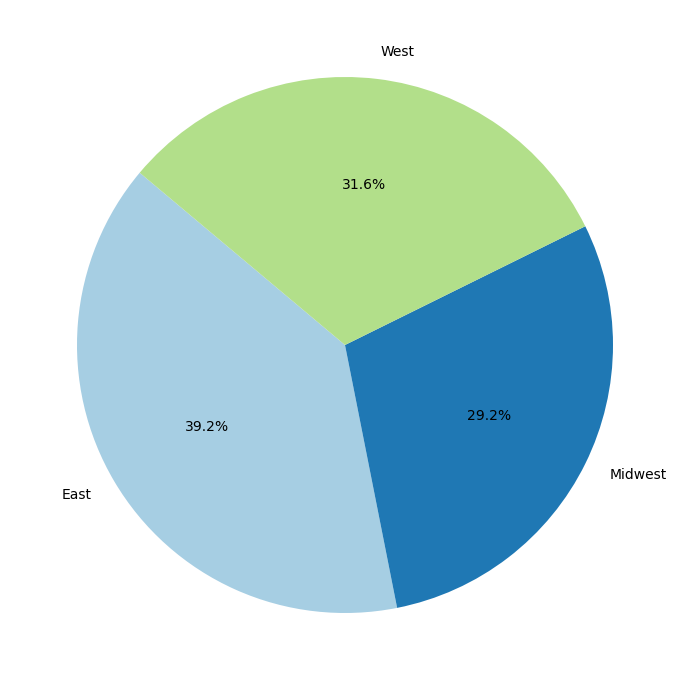

In [68]:
load_data()
print ("data load complete")
#    table_metadata = """Table: products; Columns: product_id	,product_name ,category	,brand	,price;
#                        Table: sales; Columns: sale_id	,product_id	,store_id	,quantity	,sale_date;
#                        Table: stores; Columns:store_id	,store_name	,city	,state	,region; """

Question = "show revenue by region in pie chart"
prompt = load_prompt(Question) 
print(f"Prompt:",prompt)

#llm_result = invoke_llm(prompt) 

llm_result = """SQLQuery:

SELECT st.region                          -- x coordinate (Region)
       , SUM(s.quantity * p.price) AS Revenue   -- y coordinate (Revenue)
FROM sales s
JOIN products p ON s.product_id = p.product_id
JOIN stores st ON s.store_id = st.store_id
GROUP BY st.region;


Chart: pie chart"""

print(f"AI suggestion: ")
print(llm_result)

parsed = parse_sql_and_chart(llm_result)
print(parsed)

valid, msg = query_validate(parsed["sql_query"])
print(f"Query Validation")
print(valid ,msg)
if valid:
    result = run_sql(parsed['sql_query'])   
    print (result) 
    display_chart(parsed["chart"],parsed["x_coordinate"] , parsed["y_coordinate"])
else:
    print("modify the query for the LLM to answer query")



data load complete
Prompt: You are a SQL data analyst. You help write sql code and visualize the results in charts.

        Write a SQL query to answer the following question with only the tables/columns provided in metadata: 
        Only return the SQL query starting with the Keyword "SQLQuery": Do not explain.
        Suggest a visualization to display above Result, starting with the Keyword "Chart:".Do not explain. choose one of {bar, pie, line, table}
        Add comment in query field selection to indicate 2 coordinates for the chart. use ("-- x coordinate", "-- y coordinate") Do not rename the query result field names.
        Sample:
        SQLQuery:
        SELECT d.department_name as Department             -- x coordinate (Department)
                , count(e.employee_id) as Employees        -- y coordinate (Employee Count)
        FROM employee e
        JOIN department d on e.department_id=d.department_id

        Chart: bar chart


        Metadata = {table_metadata} 
 

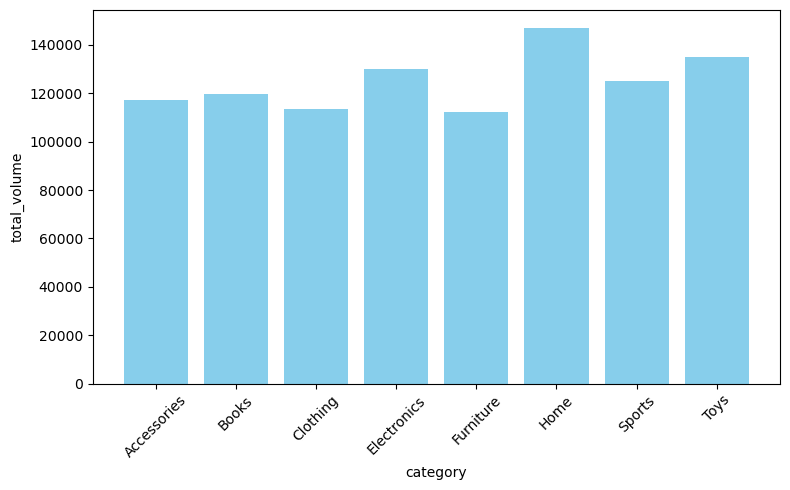

In [ ]:
load_data()
print ("data load complete")
#    table_metadata = """Table: products; Columns: product_id	,product_name ,category	,brand	,price;
#                        Table: sales; Columns: sale_id	,product_id	,store_id	,quantity	,sale_date;
#                        Table: stores; Columns:store_id	,store_name	,city	,state	,region; """

Question = "show volume of sales, revenue by product category"

#llm_result = invoke_llm_openai(Question) #$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
print(f"AI suggestion: ")
print(llm_result)

parsed = parse_sql_and_chart(llm_result.lower())
#print(parsed)

valid, msg = query_validate(parsed["sql_query"])
print(f"Query Validation")
print(valid ,msg)
if valid:
    result = run_sql(parsed['sql_query'])   
    #print (result) 
    display_chart(parsed["chart"],parsed["x_coordinate"] , parsed["y_coordinate"])
else:
    print("modify the query for the LLM to answer query")
